<a href="https://colab.research.google.com/github/sepriando/sataid-example/blob/main/Sataid_Level_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SATAID Level-1 : Introduction
A hands-on introduction to working with SATAID (.Zxxxx) satellite files in Python.

The notebook demonstrates loading data, applying visualizations, extracting values, subsetting regions, and exporting to NetCDF, GeoTIFF, and xarray.

Prepared by: **Alpon Sepriando**

Public Weather Services, BMKG — Indonesia

📧 *alpon.sepriando@bmkg.go.id*

🔗 https://github.com/sepriando/sataid-example

# 1. Environment Setup
This section handles the initial setup, including cloning the necessary repository and installing required Python packages.

In [5]:
# @title 1.1 Clone Repository and Change Directory
%cd /content
!rm -rf sataid-example

!git clone https://github.com/sepriando/sataid-example.git
%cd sataid-example

/content
Cloning into 'sataid-example'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 58 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 19.86 MiB | 8.26 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/sataid-example


In [6]:
# @title 1.2 Install Required Python Packages
# Install sataid package
!pip install sataid

#install supoorting package
!pip install cartopy rasterio

# 2. Load and Describe Sataid Data
This part focuses on loading Sataid satellite data from a specified file and displaying its key characteristics and metadata.

In [7]:
# @title 2.1 Load Sataid Data and Display Description

import sataid as sat

# Reading sataid data:
sataid_file = '/content/sataid-example/data/H09_B13_Indonesia_20240908.Z0000' #Infrared Band
#sataid_file = '/content/sataid-example/data/H09_B03_Indonesia_20240908.Z0000' #Visible band

data = sat.read_sataid(sataid_file)

# Display description
data.description()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Satellite: Himawari-9 | Channel: IR
Shape: (2000, 3000) | Units: °C
Lat: -19.9800 to 20.0000
Lon: 90.0000 to 149.9800


# 3. Plot Sataid Data
This section demonstrates how to visualize the loaded Sataid data, offering options for default plotting, adding geographical context with Cartopy, and customizing

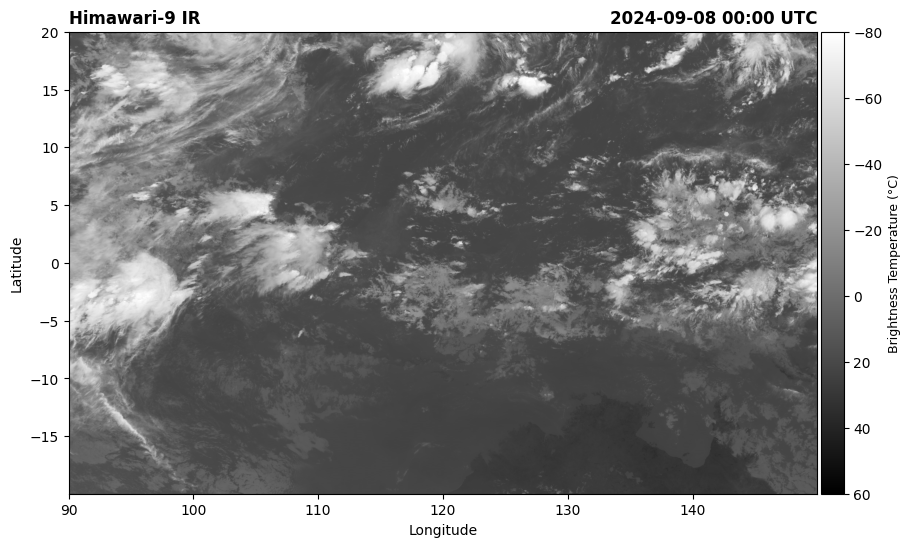

In [8]:
# @title 3.1 Plot Sataid Data (Default)

data.plot()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


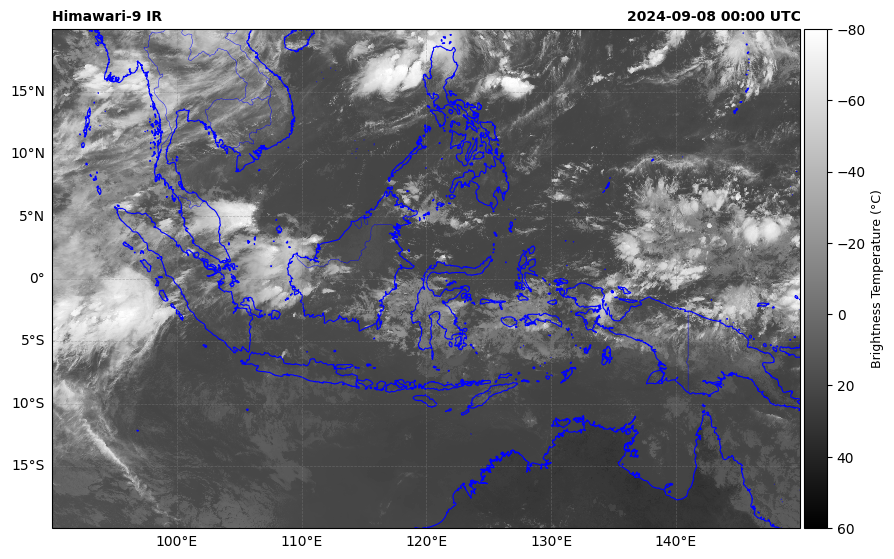

In [9]:
# @title 3.2 Plot Sataid Data with Cartopy
# Using Cartopy to add geographic context such as coastlines

data.plot(cartopy=True)

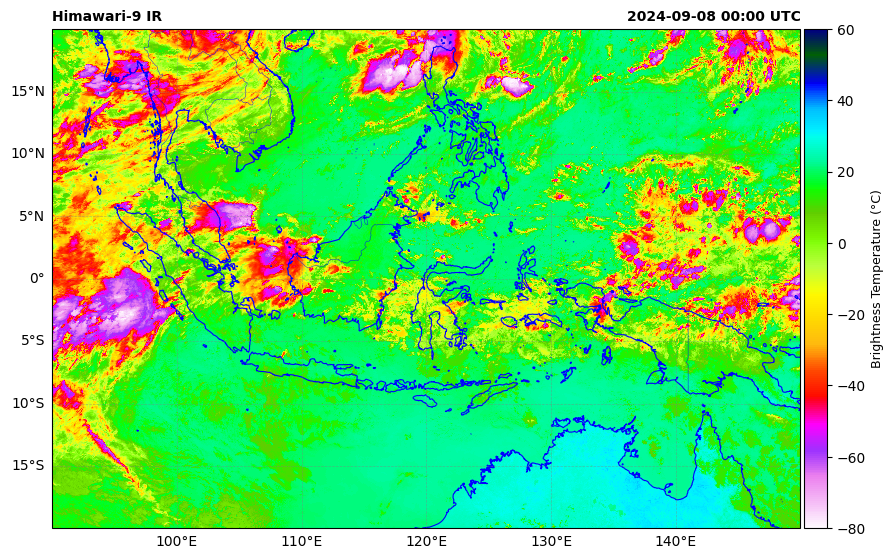

In [10]:
# @title 3.3 Plot Sataid Data with Cartopy & Custom Colormap

data.plot(cartopy=True, cmap='gist_ncar_r') # You can also try jet, terrain, etc

<table>
  <tr>
    <td style="text-align: center;">
      <img src="https://matplotlib.org/stable/_images/sphx_glr_colormaps_002_2_00x.png" width="450" />
      <br><em>Image 1: Sequential-1</em>
    </td>
    <td style="text-align: center;">
      <img src="https://matplotlib.org/stable/_images/sphx_glr_colormaps_003_2_00x.png" width="450" />
      <br><em>Image 2: Sequential-2</em>
    </td>
  </tr>
</table>

# 4. Save Plot
This covers saving the generated plots to image files, with options for default filenames or custom ones.

In [11]:
# @title 4.1 Save Plot (default)

data.savefig(cartopy=True)  #default_name +.png

Saving to H09_B13_Indonesia_20240908.Z0000.png


In [12]:
# @title 4.2 Save Plot with Custom filename

data.savefig(cartopy=True, cmap='rainbow', output_file='myplot.png')

Saving to myplot.png


# 5. Subset the Data for a Specific Region
This section shows how to select and extract a specific geographical subset from the main Sataid dataset, for example, focusing on the Borneo region.

In [13]:
# @title 5.1 Adjust slice for Borneo Area

borneo_box = data.sel(latitude=slice(7.5, -4.5), longitude=slice(108, 120))
borneo_box.description()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Satellite: Himawari-9 | Channel: IR
Shape: (600, 600) | Units: °C
Lat: -4.5000 to 7.4800
Lon: 108.0200 to 120.0000


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


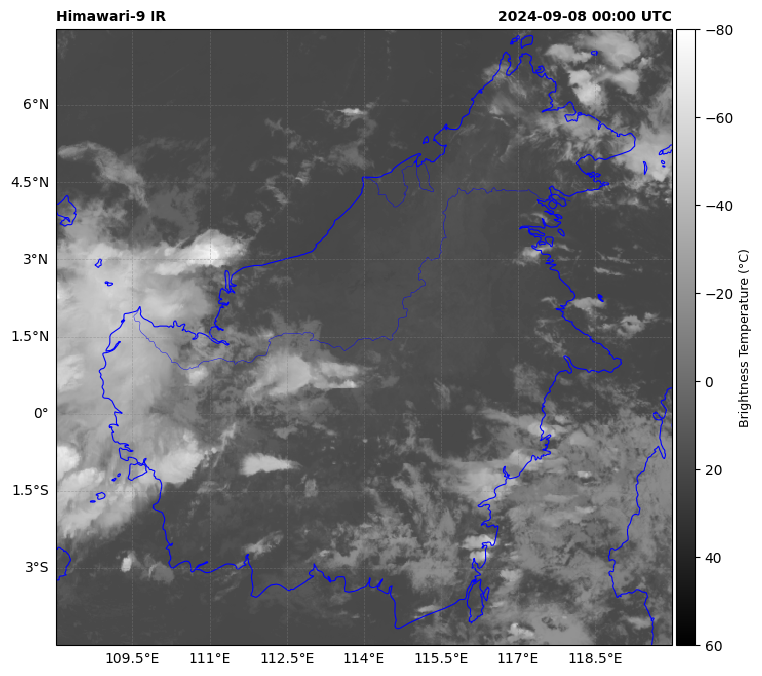

Saving to borneo_box.png


In [14]:
# @title 5.2 Plot the subsetted area

borneo_box.plot(cartopy=True)

# Save the plot of the subsetted data
borneo_box.savefig(output_file='borneo_box.png',cartopy=True)

# 6. Extract Values by Point
This explains how to retrieve data values at a precise latitude and longitude point within the Sataid dataset, using different interpolation methods.

In [15]:
# @title 6.1 Extract Values by Point

# example point
point_lat, point_lon = 1.53, 109.6

# 'nearest' method (default)
val_nearest = data.sel(latitude=point_lat, longitude=point_lon)
print(f"Value (nearest) at ({point_lat}, {point_lon}) is: {val_nearest:.2f} {data.units}")

# 'linear' method (requires scipy)
val_linear = data.sel(latitude=point_lat, longitude=point_lon, method='linear')
print(f"Value (linear) at ({point_lat}, {point_lon}) is: {val_linear:.2f} {data.units}")

Value (nearest) at (1.53, 109.6) is: -41.37 °C
Value (linear) at (1.53, 109.6) is: -41.34 °C


# 7. Convert to Other Format
This demonstrates the conversion of Sataid data into other common geospatial formats like netCDF and GeoTiff.

In [16]:
# @title 7.1 Convert to netCDF format

borneo_box.to_netcdf() #defaut filename

Exporting to NetCDF: H09_B13_Indonesia_20240908.Z0000.nc


In [17]:
# @title 7.2 Convert to GeoTiff format

borneo_box.to_geotiff('Satellite.tif') #custom filename

Saving data to GeoTIFF: Satellite.tif


# 8. Convert to Xarray and Use Its Features
This section illustrates how to transform Sataid data into an Xarray DataArray, enabling the use of Xarray's powerful capabilities for data manipulation, analysis, and plotting.

In [18]:
# @title 8.1 Convert to Xarray DataArray

xr_data = borneo_box.to_xarray()
xr_data

<xarray.DataArray 'IR' (lat: 600, lon: 600)> Size: 3MB
array([[ 20.67278442,  20.67278442,  20.77703247, ...,  -2.40869751,
         -8.80087891,  -2.84226074],
       [ 20.69884644,  20.75097046,  20.77703247, ...,  -3.31165161,
        -12.96900024,  -5.56046143],
       [ 20.72490845,  20.72490845,  20.67278442, ...,  -4.08850708,
         -3.31165161,   0.98345337],
       ...,
       [ 17.49614868,  17.49614868,  19.01717529, ...,  10.01891479,
         13.99526367,  13.7444397 ],
       [ 17.06508789,  19.09661255,  19.09661255, ...,  10.36620483,
         13.21282349,  17.33471069],
       [ 18.21941528,  19.04366455,  19.04366455, ...,  12.33922729,
         15.76088867,  18.08587036]])
Coordinates:
  * lat      (lat) float64 5kB -4.5 -4.48 -4.46 -4.44 ... 7.42 7.44 7.46 7.48
  * lon      (lon) float64 5kB 108.0 108.0 108.1 108.1 ... 120.0 120.0 120.0
Attributes:
    units:      °C
    satellite:  Himawari-9

In [19]:
# @title 8.2 Access data values

xr_data.sel(lat=-10, lon=108, method='nearest')

<xarray.DataArray 'IR' ()> Size: 8B
array(20.67278442)
Coordinates:
    lat      float64 8B -4.5
    lon      float64 8B 108.0
Attributes:
    units:      °C
    satellite:  Himawari-9

In [20]:
# @title 8.3 Calculate the mean value

xr_data.mean()

<xarray.DataArray 'IR' ()> Size: 8B
array(6.23518995)
Attributes:
    units:      °C
    satellite:  Himawari-9

In [21]:
# @title 8.4 Adjust the slice to select a valid range

subset_data = xr_data.sel(lat=slice(-5, 0), lon=slice(110, 120))
subset_data

<xarray.DataArray 'IR' (lat: 225, lon: 500)> Size: 900kB
array([[ 14.96468506,  14.96468506,  15.10241089, ...,  -2.40869751,
         -8.80087891,  -2.84226074],
       [ 15.51448975,  15.51448975,  16.36074219, ...,  -3.31165161,
        -12.96900024,  -5.56046143],
       [ 16.84890137,  17.87182007,  18.24611816, ...,  -4.08850708,
         -3.31165161,   0.98345337],
       ...,
       [-11.13443604, -10.50787964, -14.22949829, ...,   3.50655518,
          3.44432983,  -1.51517334],
       [ -9.77701416,  -7.80097046,  -7.80097046, ...,   2.94503174,
          3.10137329,  -5.76791992],
       [ -8.90875854,  -5.76791992,  -2.5418457 , ...,  -2.60852661,
         -6.84827271,  -9.70432129]])
Coordinates:
  * lat      (lat) float64 2kB -4.5 -4.48 -4.46 -4.44 ... -0.06 -0.04 -0.02
  * lon      (lon) float64 4kB 110.0 110.0 110.1 110.1 ... 120.0 120.0 120.0
Attributes:
    units:      °C
    satellite:  Himawari-9

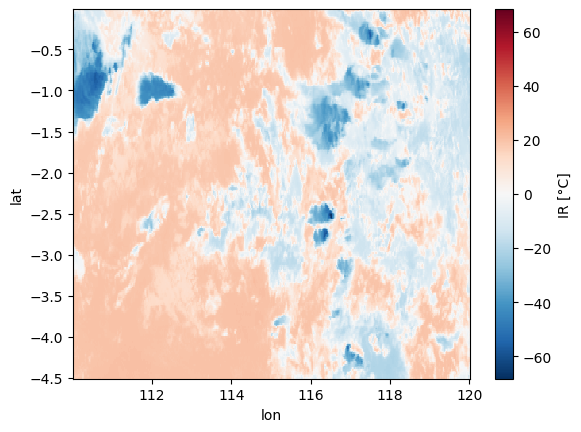

In [22]:
# @title 8.5 Plot the xarray DataArray

subset_data.plot()

(array([   225.,    728.,   6340.,  13536.,  15582.,  15065.,  26779.,
         29614.,  40778., 211353.]),
 array([-75.32131042, -65.51279144, -55.70427246, -45.89575348,
        -36.0872345 , -26.27871552, -16.47019653,  -6.66167755,
          3.14684143,  12.95536041,  22.76387939]),
 <BarContainer object of 10 artists>)

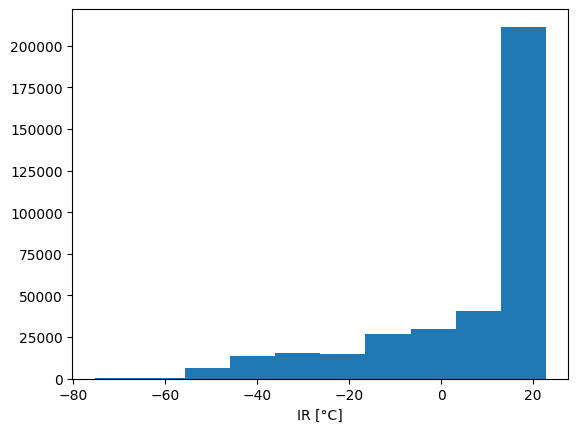

In [23]:
# @title 8.6 Creating a Histogram of the Data Values

xr_data.plot.hist()